I am testing the 100 Wolf & 100 Sheep experiments, but the second (Mark's) experiment has reduced the energy use by wolves from 1 unit to 0.5 units. My personal hypothesis is that with wolves dying out so quickly (e.g. energy <= 0), by decreasing the energy cost per tick, wolves should survive longer and hopefully keep the sheep populations in check and reduce the overall chance of total extinction.

## Data links:

In [1]:
bs100link='https://github.com/DACSS-CSSmeths-summer/abm/raw/main/experiments/experiment_100_100.csv'
marks100link='https://github.com/MarkGScott960/DACSS690C_HW4/raw/main/Wolf_Sheep_Predation_simpler%20experiment_100_100-table.csv'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1.- Load the data

Here I am loading in the two different experiments

In [3]:

# using a dictionary because some of my columns were not perfectly ordered on my experement
# Without the dictionary the heatmap was transposed and hard to compare
def read_bs_table(path):
    df = pd.read_csv(path, skiprows=6)
    return df.rename(columns={ #Extra dictionary for ordering
        "[run number]": "run_number",
        "sheep-reproduce": "sheep_reproduce",
        "wolf-reproduce": "wolf_reproduce",
        "grass-regrowth-time": "grass_regrowth_time",
        "[step]": "step",
        "count sheep": "count_sheep",
        "count wolves": "count_wolves",
    })

exp_100 = read_bs_table(bs100link)
exp_100_marks = read_bs_table(marks100link)

Take a look:

In [4]:
exp_100.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   run_number           1215 non-null   int64  
 1   sheep_reproduce      1215 non-null   int64  
 2   wolf_reproduce       1215 non-null   int64  
 3   grass_regrowth_time  1215 non-null   int64  
 4   step                 1215 non-null   int64  
 5   land_with_grass      1215 non-null   float64
 6   count_sheep          1215 non-null   int64  
 7   count_wolves         1215 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 76.1 KB


In [5]:
exp_100_marks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   run_number           1215 non-null   int64  
 1   wolf_reproduce       1215 non-null   int64  
 2   sheep_reproduce      1215 non-null   int64  
 3   grass_regrowth_time  1215 non-null   int64  
 4   step                 1215 non-null   int64  
 5   land_with_grass      1215 non-null   float64
 6   count_sheep          1215 non-null   int64  
 7   count_wolves         1215 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 76.1 KB


## 2.- Derived variables

Now we can compute the derived numbers same as before:

- **`censored`**: the run hit the time limit (1500 ticks) without resolving. We don't actually know what would have happened afterward - only that the ecosystem survived at least that long.
- **`wolves_survived`**: at least one wolf was still alive when the run ended.
- **`total_collapse`**: both sheep and wolves were gone by the end (the ecosystem fully collapsed).

In [6]:
def add_derived(df, time_limit=1500):
    df = df.copy()
    df["censored"] = df["step"] == time_limit
    df["sheep_survived"] = df["count_sheep"] > 0
    df["wolves_survived"] = df["count_wolves"] > 0
    df["total_collapse"] = (~df["sheep_survived"]) & (~df["wolves_survived"])
    return df

exp_100 = add_derived(exp_100)
exp_100_marks = add_derived(exp_100_marks)

exp_100["config"] = "100_100_Base"
exp_100_marks["config"] = "Reduced_Wolf_Hunger"

both = pd.concat([exp_100, exp_100_marks], ignore_index=True)
both.head()

,run_number,sheep_reproduce,wolf_reproduce,grass_regrowth_time,step,land_with_grass,count_sheep,count_wolves,censored,sheep_survived,wolves_survived,total_collapse,config
0,4,4,4,175,1500,44.367551,22,0,True,True,False,False,100_100_Base
1,5,4,4,175,1500,59.630911,22,0,True,True,False,False,100_100_Base
2,6,4,4,175,1500,69.511726,49,0,True,True,False,False,100_100_Base
3,3,4,4,150,1500,53.364091,22,0,True,True,False,False,100_100_Base
4,7,4,4,200,1500,36.447520,10,0,True,True,False,False,100_100_Base


## 3.- Descriptive summary

For each configuration, we summarize the wolf $\rightarrow$ sheep $\rightarrow$ grass dependency chain into four numbers: what fraction of runs ended in total collapse, what fraction still had sheep alive (the sheep $\rightarrow$ grass link holding), what fraction still had wolves alive (the wolf $\rightarrow$ sheep link holding), and what fraction were censored (hit the time limit before resolving).

In [7]:
summary_table = both.groupby("config")[["total_collapse", "sheep_survived", "wolves_survived", "censored"]].mean()
summary_table

,total_collapse,sheep_survived,wolves_survived,censored
config,,,,
100_100_Base,0.750617,0.249383,0.0,0.249383
Reduced_Wolf_Hunger,0.772016,0.227984,0.0,0.227984



**ANALYSIS 1:**

The first thing to notice is the `wolves_survived` column: 0.0 in both rows.  Across 1,215 runs of the base model and 1,215 runs of mine, not one run ended with a wolf still standing. Halving the wolves' per-tick energy cost (1  $\rightarrow$  0.5) was exactly the intervention I expected to move that number. Unfortunately, it didn't budge it at all. Whatever is killing the wolves, it isn't the metabolic drain of moving.

The other two numbers move slightly, and in the wrong direction: total collapse goes from 0.751 in the base to 0.772 in mine, and sheep survival correspondingly falls from 0.249 to 0.228. So making wolves cheaper to run made the ecosystem slightly *less* likely to survive, not more. I believe that a wolf that burns half as much energy stays alive longer between kills, so it gets more hunting attempts before starving. More attempts mean more wolves in general. More wolves means more hunting pressure. More hunting pressure on the sheep, and the sheep are the ones holding the whole chain up so there is nowhere to pass on the energy deficit. The wolves still die - they just take a few more sheep down with them first.

And as before with your two experiments, `censored` and `sheep_survived` are identical in both rows.  A run can only end before tick 1500 by hitting the exit condition, and with wolves always extinct, the only way to trip that condition is for the sheep to die too. So "survived to the time limit" and "still had sheep" are the same event in both.

## 4.- Heatmap - probability of total collapse, by parameters

Each cell shows the proportion of runs (averaged over the 3 repetitions) that ended in total collapse, for a given combination of `sheep-reproduce` and `wolf-reproduce`.

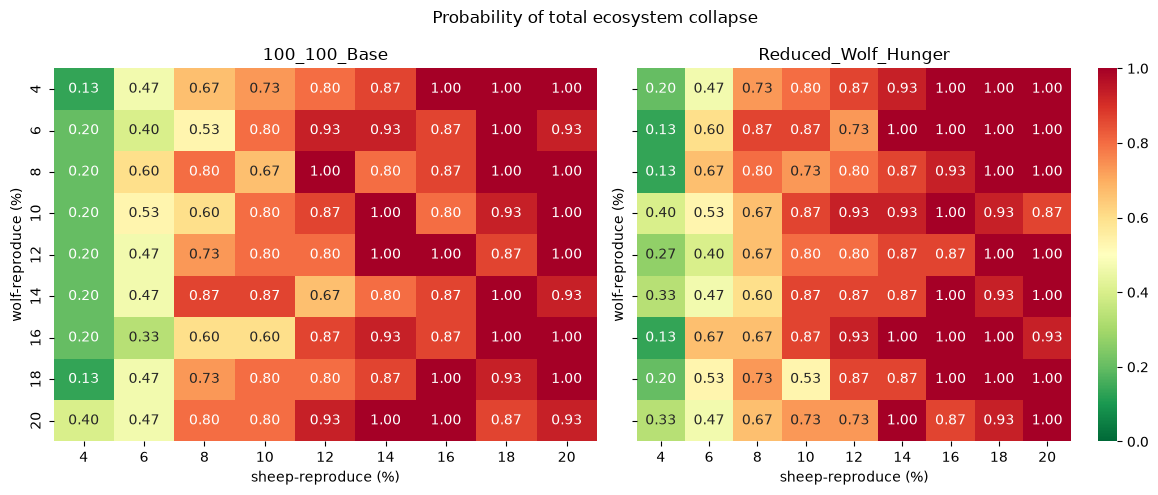

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (config_name, sub) in zip(axes, both.groupby("config")):
    pivot = sub.pivot_table(index="wolf_reproduce", columns="sheep_reproduce",
                             values="total_collapse", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=1,
                annot=True, fmt=".2f", cbar=(ax is axes[-1]))
    ax.set_title(config_name)
    ax.set_xlabel("sheep-reproduce (%)")
    ax.set_ylabel("wolf-reproduce (%)")

plt.suptitle("Probability of total ecosystem collapse")
plt.tight_layout()
plt.show()

**ANALYSIS 2:**

When reading horizontally we see that, faster-reproducing sheep graze the grass down faster than it regrows, and the sheep $\rightarrow$ grass link breaks. This means that eventually the sheep starve and total collapse. Following a column up and down instead: the base row averages sit between 0.71 and 0.80, mine between 0.74 and 0.80, with no trend in either. `wolf-reproduce` does essentially nothing across its whole range. This makes sense, since wolves die out quickly in every simulation. 

The difference between panels is a small uniform shift. Mine is a shade redder almost everywhere - at `sheep-reproduce = 6` the base averages 0.47 and mine 0.53, at 16 the base is 0.92 and mine 0.96 - but the left column still holds out (0.21 vs 0.24, with individual cells as low as 0.13 in both), and the right column is saturated at 0.98 in both. My change nudged the whole surface a little further toward collapse without touching the specific parameter controls it.

## 5.- Kaplan-Meier survival curves and the log-rank test


### Installation:

In [9]:
### do you have it?
! pip show lifelines

Name: lifelines
Version: 0.30.3
Summary: Survival analysis in Python, including Kaplan Meier, Nelson Aalen and regression
Home-page: https://github.com/CamDavidsonPilon/lifelines
Author: Cameron Davidson-Pilon
Author-email: cam.davidson.pilon@gmail.com
License: MIT
Location: C:\Users\markg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages
Requires: autograd, autograd-gamma, formulaic, matplotlib, numpy, pandas, scipy
Required-by: 


In [10]:
### IF NOT, then uncomment this line and run it
# !pip install lifelines --quiet

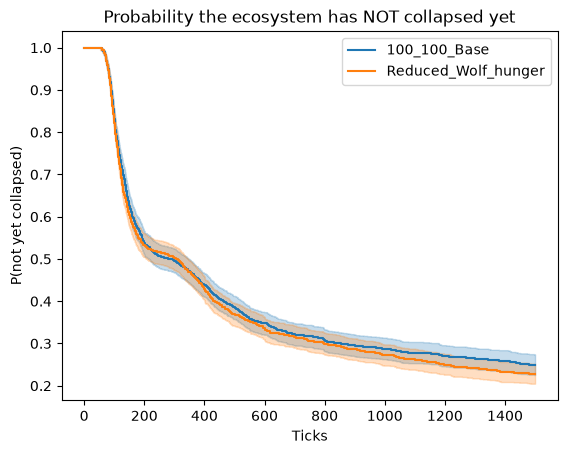

In [11]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

both["event"] = ~both["censored"]  # event = 1 if collapse actually happened before the time limit

sub_100 = both[both["config"] == "100_100_Base"]
sub_100_marks = both[both["config"] == "Reduced_Wolf_Hunger"]

kmf_100 = KaplanMeierFitter()
kmf_100_marks = KaplanMeierFitter()

ax = plt.subplot(111)
kmf_100.fit(sub_100["step"], event_observed=sub_100["event"], label="100_100_Base")
kmf_100.plot_survival_function(ax=ax)


kmf_100_marks.fit(sub_100_marks["step"], event_observed=sub_100_marks["event"], label="Reduced_Wolf_hunger")
kmf_100_marks.plot_survival_function(ax=ax)

plt.title("Probability the ecosystem has NOT collapsed yet")
plt.xlabel("Ticks")
plt.ylabel("P(not yet collapsed)")
plt.show()

**ANALYSIS 3:**

These two curves are nearly on top of each other, which is what we should expect given the results above. Both fall off a cliff between roughly tick 50 and tick 200 - from 1.00 down to about 0.54 (base) and 0.53 (mine) - then flatten into a shelf around 0.50 through tick 300 before resuming a slow trend downward. Most ecosystems that will fail, fail quickly.

Where the curves do separate, they separate in two directions, which is a good sign that nothing real is happening. Mine crosses the 50% line slightly *later*, but from about tick 400 onward mine runs slightly below, ending at 0.228 against the base's 0.249 - the same 22.8% vs 24.9% censoring rate from the summary table. So my version is marginally slower to reach the halfway point and marginally worse in the long tail. 

The shaded confidence bands overlap across the entire x-axis, never pulling apart. They also widen toward the right in both curves, because by tick 1200 only a couple hundred runs are still at risk and the estimate gets correspondingly noisier. Eyeballing it, I would say there's no meaningful distinction here worth interpreting - which the test below confirms.

In [12]:
results = logrank_test(sub_100["step"], sub_100_marks["step"],
                        event_observed_A=sub_100["event"],
                        event_observed_B=sub_100_marks["event"])
results.print_summary()

**ANALYSIS 4:**

The test statistic is 1.25 on 1 degree of freedom, and the threshold for significance at the conventional 0.05 level is 3.84. We don't get anywhere near it. The p-value is 0.26 and the `-log2(p)` column reads 1.93. 

Halving the wolves' per-tick energy cost  produced no detectable change in when the ecosystem collapses, and no change at all in whether wolves survive it (0% either way). I would have assumed that a massive reduction in one of the three main factors of mortality would have corresponded to a lower likelihood of collapse. In my mind, more wolves meant a higher downward pressure on sheep that would reduce the likelihood of over grazing.

Reading it alongside the heatmap, I think the reason is that I intervened on a link in the chain that wasn't the binding constraint. The heatmap says collapse is governed by `sheep-reproduce` - the sheep $\rightarrow$ grass relationship - while `wolf-reproduce` is inert across its entire range. The wolf $\rightarrow$ sheep link has already failed in every single run of both models. Making wolves more energy-efficient adjusts a subsystem that was never determining the outcome. If I ran this again, I'd modify grass regrowth or sheep energy gain instead, since that's where the model's sensitivity actually lives.